# (7) RecurrentPPO — Sequence-Aware Navigation

## Motivation

In Notebook (6), MLP-PPO peaked at ~48% SR on near starts (3–5 steps) and dropped off sharply at longer distances. The fundamental issue is that a single-frame observation carries no directional cue — the 512-d tile embedding encodes visual appearance but says nothing about where the tumor is relative to the current position.

**Hypothesis**: even though individual frames are uninformative about direction, there may be a useful signal in the *sequence* of observations. As the agent moves toward or away from the tumor, the embeddings it sees should shift in some consistent way. An LSTM should be able to pick up on this trend across steps.

## Approach

- Replace `PPO(MlpPolicy)` with `RecurrentPPO(MlpLstmPolicy)` from sb3-contrib
- LSTM hidden state is maintained across steps and reset at the start of each episode
- Training setup: `random_tissue` start mode (mixed-distance), same as Notebook (6) Section 8
- Baseline: the saved MLP-PPO results from Notebook (6)

## 1. Imports & Setup

In [ ]:
import os, time, datetime, importlib, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# RL
import gymnasium
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

# Project env
import wsi_env as wsi_env_module
importlib.reload(wsi_env_module)
from wsi_env import WSIEnv

# Constants
H5_PATH = "tile_database/tumor_011.h5"
MAX_STEPS = 2000
EMBEDDING_SUFFIX = "_i"
RUN_TAG = f"rppo_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"

REWARD_CFG = dict(
    step_penalty=-0.01,
    revisit_penalty=-0.2,
    tumor_reward=50.0,
    timeout_penalty=-1.0,
    background_penalty=-0.5,
)

print(f"gymnasium:   {gymnasium.__version__}")
print(f"sb3-contrib: {__import__('sb3_contrib').__version__}")
print(f"Run tag:     {RUN_TAG}")

gymnasium:   1.2.3
sb3-contrib: 2.7.1
Run tag:     rppo_20260323_015450


## 2. Callback

In [2]:
class TrainingCallback(BaseCallback):
    """Track episode stats during training."""

    def __init__(self, check_freq: int = 10000, window: int = 50, verbose: int = 1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.window = window
        self.episode_rewards = []
        self.episode_lengths = []
        self.successes = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        dones = self.locals.get("dones", [])
        if dones is not None:
            for i, done in enumerate(dones):
                if done and infos is not None and i < len(infos):
                    ep = infos[i].get("episode")
                    if ep is not None:
                        self.episode_rewards.append(ep["r"])
                        self.episode_lengths.append(ep["l"])
                    self.successes.append(infos[i].get("success", False))

        if self.num_timesteps % self.check_freq == 0 and len(self.episode_rewards) > 0:
            n = min(self.window, len(self.episode_rewards))
            avg_r = np.mean(self.episode_rewards[-n:])
            avg_l = np.mean(self.episode_lengths[-n:])
            sr = np.mean(self.successes[-n:]) * 100
            print(f"[Step {self.num_timesteps:>7d}] "
                  f"last{n} avg_R={avg_r:+.2f}  avg_L={avg_l:.0f}  "
                  f"SR={sr:.1f}%  eps={len(self.episode_rewards)}")
        return True

    @property
    def recent_success_rate(self) -> float:
        if len(self.successes) < self.window:
            return 0.0
        return float(np.mean(self.successes[-self.window:]))

    def _on_training_end(self):
        n = len(self.episode_rewards)
        if n > 0:
            last = min(50, n)
            print(f"  Training done: {n} episodes, "
                  f"last{last} avg_R={np.mean(self.episode_rewards[-last:]):+.2f}  "
                  f"avg_L={np.mean(self.episode_lengths[-last:]):.0f}  "
                  f"SR={np.mean(self.successes[-last:])*100:.1f}%")

## 3. Environment Setup & Sanity Check

In [3]:
monitor_dir = f"monitor_logs_{RUN_TAG}"
os.makedirs(monitor_dir, exist_ok=True)

env = WSIEnv(
    h5_path=H5_PATH,
    max_steps=MAX_STEPS,
    embedding_suffix=EMBEDDING_SUFFIX,
    enable_stop=False,
    start_mode="random_tissue",
    reward_cfg=REWARD_CFG,
)
env = Monitor(env, monitor_dir)

print(f"Obs space: {env.observation_space.shape}")
print(f"Act space: {env.action_space}")
print(f"Grid: {env.env.n_rows} x {env.env.n_cols}")
print(f"Tissue tiles: {env.env.tissue_grid.sum()}")
print(f"Tumor tiles:  {env.env.tumor_grid.sum()}")
print(f"Start mode: {env.env.start_mode}")

Obs space: (1660,)
Act space: Discrete(4)
Grid: 493 x 218
Tissue tiles: 24347
Tumor tiles:  1108
Start mode: random_tissue


## 4. RecurrentPPO Model

Key differences from the MLP baseline:
- `MlpLstmPolicy` appends an LSTM layer after the MLP feature extractor
- Hidden state persists across timesteps within an episode; reset at episode boundaries
- The agent can exploit temporal patterns across its observation history
- `n_steps` should be long enough to cover a meaningful chunk of each episode

In [ ]:
TOTAL_TIMESTEPS = 500_000

model = RecurrentPPO(
    policy="MlpLstmPolicy",
    env=env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.999,
    gae_lambda=0.98,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=0,
    device="cpu",
    policy_kwargs=dict(
        net_arch=[256, 256],       # MLP layers before LSTM
        lstm_hidden_size=256,       # LSTM hidden dimension
        n_lstm_layers=1,
    ),
    tensorboard_log=f"./tb_logs_{RUN_TAG}",
    seed=42,
)

# Print model architecture and parameter count
print("Model architecture:")
print(model.policy)
total_params = sum(p.numel() for p in model.policy.parameters())
print(f"\nTotal parameters: {total_params:,}")

Model architecture:
RecurrentActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): Tanh()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): Tanh()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=256, out_features=4, bias=True)
  (value_net): Linear(in_features=256, out_features=1, bias=True)
  (lstm_actor): LSTM(1660, 256)
  (lstm_critic): LSTM(1660, 256)
)

Total parameters: 4,192,517

## 5. Training

In [5]:
callback = TrainingCallback(check_freq=10000, window=50)

t0 = time.time()
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)
elapsed = time.time() - t0

print(f"\nTraining completed in {elapsed:.1f}s ({elapsed/60:.1f}min)")

[Step   10000] last5 avg_R=-268.60  avg_L=2000  SR=0.0%  eps=5
[Step   20000] last10 avg_R=-186.58  avg_L=1802  SR=10.0%  eps=10
[Step   30000] last15 avg_R=-143.11  avg_L=1868  SR=6.7%  eps=15
[Step   40000] last21 avg_R=-105.82  avg_L=1817  SR=9.5%  eps=21
[Step   50000] last29 avg_R=-75.27  avg_L=1665  SR=17.2%  eps=29
[Step   60000] last35 avg_R=-64.00  avg_L=1668  SR=17.1%  eps=35
[Step   70000] last42 avg_R=-53.47  avg_L=1628  SR=19.0%  eps=42
[Step   80000] last47 avg_R=-50.04  avg_L=1668  SR=17.0%  eps=47
[Step   90000] last50 avg_R=-24.87  avg_L=1611  SR=20.0%  eps=54
[Step  100000] last50 avg_R=-10.99  avg_L=1611  SR=20.0%  eps=60
[Step  110000] last50 avg_R=-5.97  avg_L=1572  SR=22.0%  eps=66
[Step  120000] last50 avg_R=-7.11  avg_L=1609  SR=20.0%  eps=71
[Step  130000] last50 avg_R=-8.47  avg_L=1648  SR=18.0%  eps=78
[Step  140000] last50 avg_R=-9.04  avg_L=1648  SR=18.0%  eps=83
[Step  150000] last50 avg_R=-20.32  avg_L=1726  SR=14.0%  eps=88
[Step  160000] last50 avg_R=-1

## 6. Training Curves

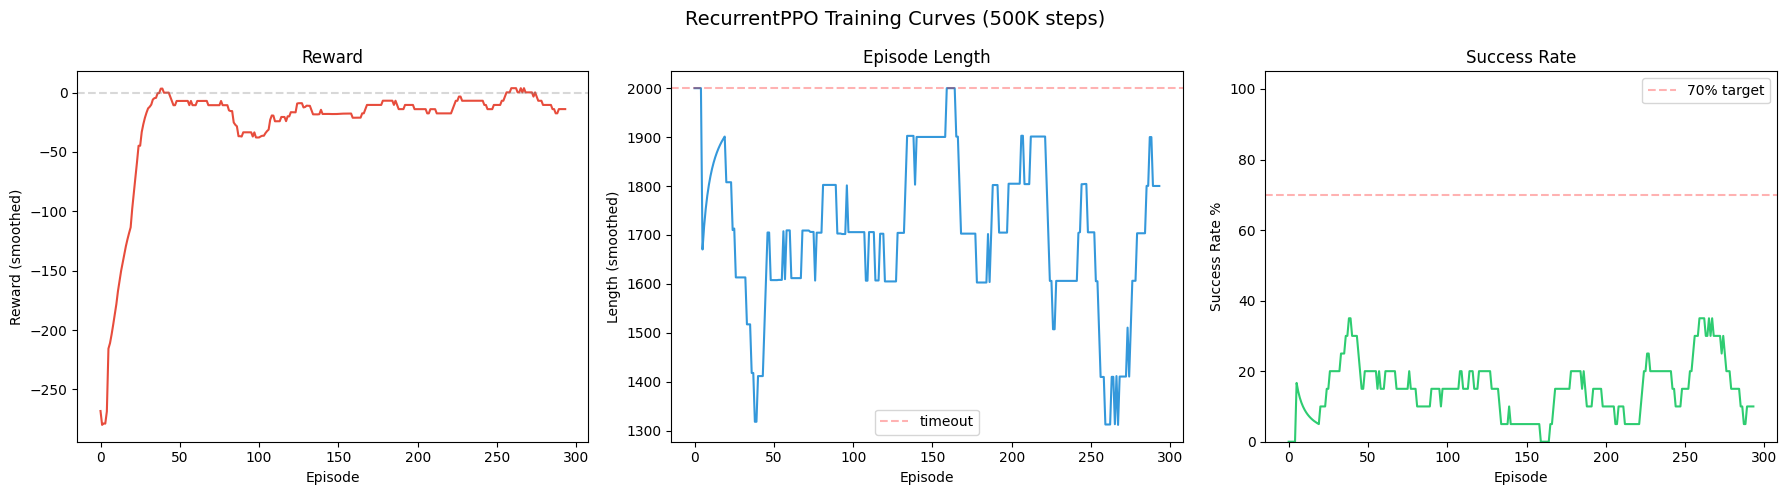

Total episodes: 294
Last 50: avg_R=-6.86, avg_L=1605.4, SR=20.0%


In [6]:
df = pd.read_csv(os.path.join(monitor_dir, "monitor.csv"), skiprows=1)
df.columns = ['r', 'l', 't']

window = 20
df['r_smooth'] = df['r'].rolling(window, min_periods=1).mean()
df['l_smooth'] = df['l'].rolling(window, min_periods=1).mean()
df['success'] = (df['r'] > 0).astype(float)
df['sr_smooth'] = df['success'].rolling(window, min_periods=1).mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'RecurrentPPO Training Curves ({TOTAL_TIMESTEPS//1000}K steps)', fontsize=14)

axes[0].plot(df['r_smooth'], color='#e74c3c')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Reward (smoothed)')
axes[0].set_title('Reward'); axes[0].axhline(0, color='gray', ls='--', alpha=0.3)

axes[1].plot(df['l_smooth'], color='#3498db')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Length (smoothed)')
axes[1].set_title('Episode Length')
axes[1].axhline(2000, color='red', ls='--', alpha=0.3, label='timeout')
axes[1].legend()

axes[2].plot(df['sr_smooth'], color='#2ecc71')
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Success Rate %')
axes[2].set_title('Success Rate')
axes[2].axhline(70, color='red', ls='--', alpha=0.3, label='70% target')
axes[2].set_ylim(0, 105); axes[2].legend()

plt.tight_layout()
plt.show()

n_eps = len(df)
last_n = min(50, n_eps)
print(f"Total episodes: {n_eps}")
print(f"Last {last_n}: avg_R={df['r'].tail(last_n).mean():+.2f}, "
      f"avg_L={df['l'].tail(last_n).mean():.1f}, "
      f"SR={df['success'].tail(last_n).mean()*100:.1f}%")

## 7. Deterministic Evaluation

In [7]:
def evaluate_recurrent(model, h5_path, start_mode, dist_range,
                       n_episodes=50, max_steps=2000, seed=123):
    """Run deterministic evaluation for RecurrentPPO.
    
    RecurrentPPO needs lstm_states management during rollout.
    """
    eval_env = WSIEnv(
        h5_path=h5_path,
        max_steps=max_steps,
        embedding_suffix=EMBEDDING_SUFFIX,
        enable_stop=False,
        start_mode=start_mode,
        start_dist_range=dist_range,
    )

    rng = np.random.RandomState(seed)
    if start_mode == 'distance_band' and dist_range is not None:
        pool = eval_env.get_start_pool(dist_range[0], dist_range[1])
    else:
        pool = np.argwhere(eval_env.tissue_grid & ~eval_env.tumor_grid)

    indices = rng.choice(len(pool), size=min(n_episodes, len(pool)), replace=False)
    starts = [(int(pool[i][0]), int(pool[i][1])) for i in indices]

    results = []
    for start in starts:
        eval_env.fixed_starts = [start]
        eval_env.start_mode = 'fixed'
        eval_env._start_idx = 0

        obs, info = eval_env.reset()
        trajectory = [(info['row'], info['col'])]
        total_r = 0.0
        done = False

        # RecurrentPPO needs lstm_states tracking
        lstm_states = None
        episode_start = np.ones((1,), dtype=bool)

        while not done:
            action, lstm_states = model.predict(
                obs, state=lstm_states, episode_start=episode_start,
                deterministic=True
            )
            episode_start = np.zeros((1,), dtype=bool)
            obs, reward, terminated, truncated, info = eval_env.step(action)
            trajectory.append((info['row'], info['col']))
            total_r += reward
            done = terminated or truncated

        results.append({
            'start': start,
            'trajectory': trajectory,
            'reward': total_r,
            'length': len(trajectory) - 1,
            'success': info.get('success', False),
        })

    eval_env.close()
    return results

In [8]:
eval_configs = [
    ('2a (3-5)',       'distance_band', (3, 5)),
    ('2b (10-20)',     'distance_band', (10, 20)),
    ('2c (all tissue)','random_tissue',  None),
]

eval_results = {}
for eval_name, mode, dr in eval_configs:
    res = evaluate_recurrent(model, H5_PATH, mode, dr, n_episodes=50)
    successes = sum(1 for r in res if r['success'])
    lengths = [r['length'] for r in res]
    rewards = [r['reward'] for r in res]
    eval_results[eval_name] = res

    print(f"Eval [{eval_name}]: {successes}/{len(res)} success "
          f"({successes/len(res)*100:.1f}%)  "
          f"avg_len={np.mean(lengths):.1f}  avg_R={np.mean(rewards):+.2f}")

Eval [2a (3-5)]: 27/50 success (54.0%)  avg_len=924.5  avg_R=+17.30
Eval [2b (10-20)]: 14/50 success (28.0%)  avg_len=1448.3  avg_R=-1.20
Eval [2c (all tissue)]: 10/50 success (20.0%)  avg_len=1604.9  avg_R=-6.85


## 8. Comparison: MLP-PPO vs RecurrentPPO

Load the monitor CSV from Notebook (6)'s mixed-distance MLP-PPO run as the baseline.

In [ ]:
# Load the MLP-PPO baseline monitor from Notebook (6) mixed training
mixed_dirs = sorted(glob.glob("monitor_logs_mixed_*"))
if mixed_dirs:
    baseline_dir = mixed_dirs[-1]  # use the most recent run
    print(f"Baseline MLP-PPO monitor dir: {baseline_dir}")
    df_baseline = pd.read_csv(os.path.join(baseline_dir, "monitor.csv"), skiprows=1)
    df_baseline.columns = ['r', 'l', 't']
    df_baseline['success'] = (df_baseline['r'] > 0).astype(float)
    last_n_base = min(50, len(df_baseline))
    print(f"Baseline: {len(df_baseline)} episodes, "
          f"last{last_n_base} SR={df_baseline['success'].tail(last_n_base).mean()*100:.1f}%")
else:
    df_baseline = None
    print("No MLP-PPO baseline monitor found")

# Run deterministic eval on the saved MLP-PPO model for a fair head-to-head comparison
mlp_model_files = sorted(glob.glob("ppo_mixed_*.zip"))
baseline_eval = {}
if mlp_model_files:
    mlp_model_path = mlp_model_files[-1]
    print(f"\nLoading MLP-PPO model: {mlp_model_path}")
    mlp_model = PPO.load(mlp_model_path)

    for eval_name, mode, dr in eval_configs:
        eval_env = WSIEnv(
            h5_path=H5_PATH,
            max_steps=MAX_STEPS,
            embedding_suffix=EMBEDDING_SUFFIX,
            enable_stop=False,
            start_mode=mode,
            start_dist_range=dr,
        )
        rng_b = np.random.RandomState(123)  # same seed as RecurrentPPO eval
        if mode == 'distance_band' and dr is not None:
            pool = eval_env.get_start_pool(dr[0], dr[1])
        else:
            pool = np.argwhere(eval_env.tissue_grid & ~eval_env.tumor_grid)
        indices = rng_b.choice(len(pool), size=min(50, len(pool)), replace=False)
        starts = [(int(pool[i][0]), int(pool[i][1])) for i in indices]

        res_b = []
        for start in starts:
            eval_env.fixed_starts = [start]
            eval_env.start_mode = 'fixed'
            eval_env._start_idx = 0
            obs, info = eval_env.reset()
            trajectory = [(info['row'], info['col'])]
            total_r = 0.0
            done = False
            while not done:
                action, _ = mlp_model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = eval_env.step(action)
                trajectory.append((info['row'], info['col']))
                total_r += reward
                done = terminated or truncated
            res_b.append({
                'start': start, 'trajectory': trajectory,
                'reward': total_r, 'length': len(trajectory) - 1,
                'success': info.get('success', False),
            })
        eval_env.close()
        baseline_eval[eval_name] = res_b
        sr_b = sum(1 for r in res_b if r['success']) / len(res_b) * 100
        print(f"MLP-PPO eval [{eval_name}]: SR={sr_b:.1f}%")
else:
    print("No saved MLP-PPO model found for comparison")

Baseline MLP-PPO monitor dir: monitor_logs_mixed_20260323_005812
Baseline: 354 episodes, last50 SR=34.0%

Loading MLP-PPO model: ppo_mixed_mixed_20260323_005812.zip


d:\ProgramData\Anaconda3\envs\wsi-rl\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


MLP-PPO eval [2a (3-5)]: SR=48.0%
MLP-PPO eval [2b (10-20)]: SR=20.0%
MLP-PPO eval [2c (all tissue)]: SR=6.0%


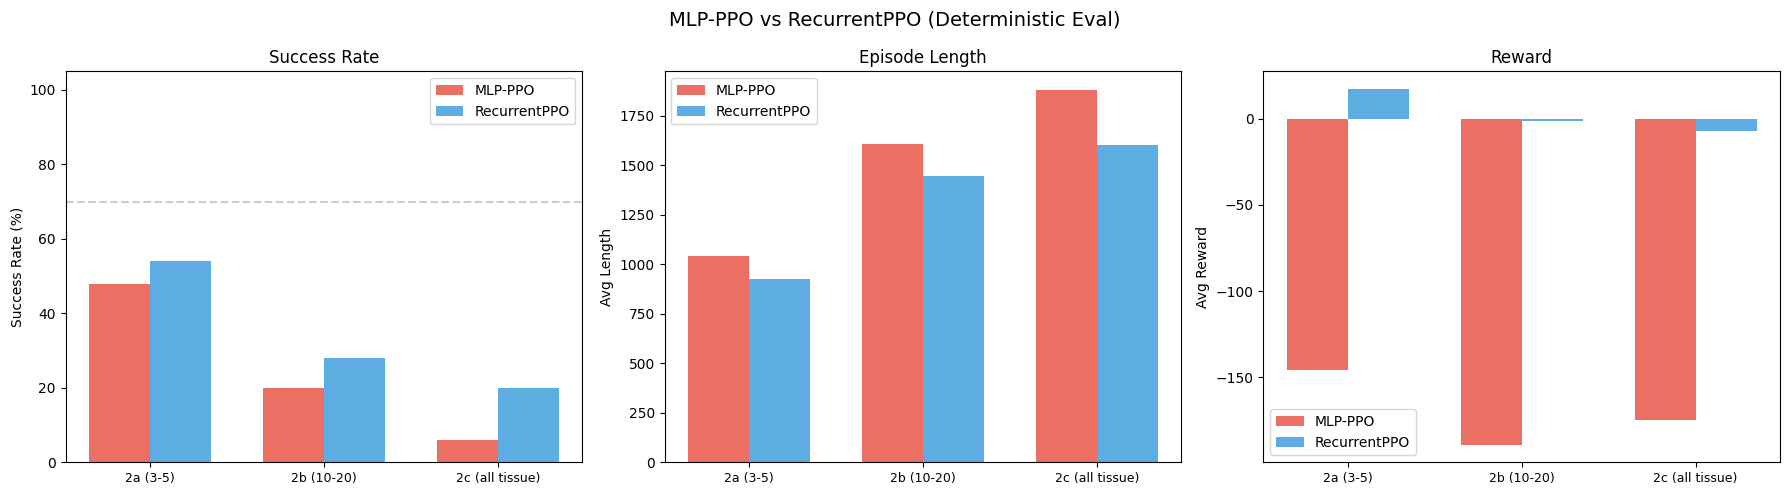


Model                2a (3-5)           2b (10-20)         2c (all tissue)   
MLP-PPO               48.0%  L=1042.8   20.0%  L=1607.6    6.0%  L=1881.3
RecurrentPPO          54.0%  L= 924.5   28.0%  L=1448.3   20.0%  L=1604.9


In [ ]:
# Bar chart comparison
eval_names = list(eval_results.keys())

sr_rppo = [np.mean([r['success'] for r in eval_results[n]]) * 100 for n in eval_names]
len_rppo = [np.mean([r['length'] for r in eval_results[n]]) for n in eval_names]
rew_rppo = [np.mean([r['reward'] for r in eval_results[n]]) for n in eval_names]

if baseline_eval:
    sr_mlp = [np.mean([r['success'] for r in baseline_eval[n]]) * 100 for n in eval_names]
    len_mlp = [np.mean([r['length'] for r in baseline_eval[n]]) for n in eval_names]
    rew_mlp = [np.mean([r['reward'] for r in baseline_eval[n]]) for n in eval_names]
else:
    sr_mlp = [0] * len(eval_names)
    len_mlp = [0] * len(eval_names)
    rew_mlp = [0] * len(eval_names)

x = np.arange(len(eval_names))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MLP-PPO vs RecurrentPPO (Deterministic Eval)', fontsize=14)

# Success Rate
axes[0].bar(x - width/2, sr_mlp, width, label='MLP-PPO', color='#e74c3c', alpha=0.8)
axes[0].bar(x + width/2, sr_rppo, width, label='RecurrentPPO', color='#3498db', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(eval_names, fontsize=9)
axes[0].set_ylabel('Success Rate (%)'); axes[0].set_title('Success Rate')
axes[0].axhline(70, color='gray', ls='--', alpha=0.4)
axes[0].set_ylim(0, 105); axes[0].legend()

# Length
axes[1].bar(x - width/2, len_mlp, width, label='MLP-PPO', color='#e74c3c', alpha=0.8)
axes[1].bar(x + width/2, len_rppo, width, label='RecurrentPPO', color='#3498db', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(eval_names, fontsize=9)
axes[1].set_ylabel('Avg Length'); axes[1].set_title('Episode Length')
axes[1].legend()

# Reward
axes[2].bar(x - width/2, rew_mlp, width, label='MLP-PPO', color='#e74c3c', alpha=0.8)
axes[2].bar(x + width/2, rew_rppo, width, label='RecurrentPPO', color='#3498db', alpha=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels(eval_names, fontsize=9)
axes[2].set_ylabel('Avg Reward'); axes[2].set_title('Reward')
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*70)
print(f"{'Model':<20} {'2a (3-5)':<18} {'2b (10-20)':<18} {'2c (all tissue)':<18}")
print("="*70)
print(f"{'MLP-PPO':<20} {sr_mlp[0]:>5.1f}%  L={len_mlp[0]:>6.1f}"
      f"  {sr_mlp[1]:>5.1f}%  L={len_mlp[1]:>6.1f}"
      f"  {sr_mlp[2]:>5.1f}%  L={len_mlp[2]:>6.1f}")
print(f"{'RecurrentPPO':<20} {sr_rppo[0]:>5.1f}%  L={len_rppo[0]:>6.1f}"
      f"  {sr_rppo[1]:>5.1f}%  L={len_rppo[1]:>6.1f}"
      f"  {sr_rppo[2]:>5.1f}%  L={len_rppo[2]:>6.1f}")
print("="*70)

## 9. Trajectory Visualization

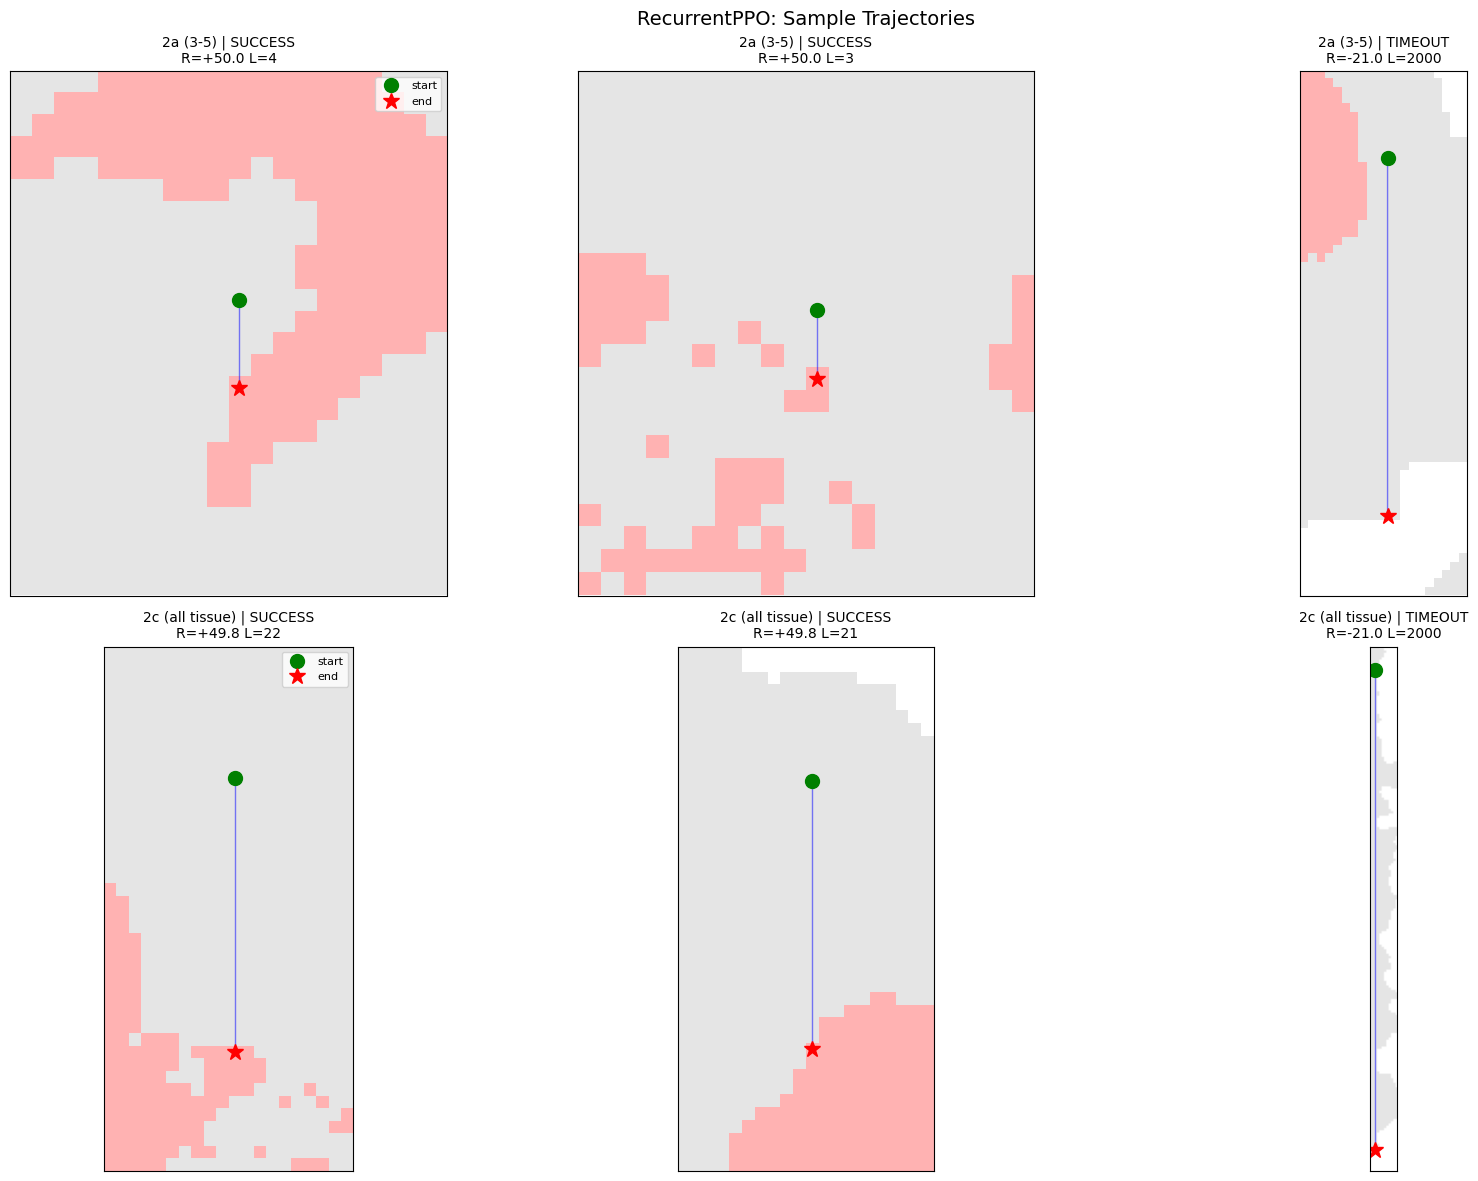

In [11]:
vis_env = WSIEnv(H5_PATH, max_steps=MAX_STEPS, embedding_suffix=EMBEDDING_SUFFIX)

n_show = 3
fig, axes = plt.subplots(2, n_show, figsize=(6 * n_show, 12))
fig.suptitle('RecurrentPPO: Sample Trajectories', fontsize=14)

for row_i, (eval_name, mode, dr) in enumerate(
    [('2a (3-5)', 'distance_band', (3, 5)),
     ('2c (all tissue)', 'random_tissue', None)]
):
    res = eval_results[eval_name]
    success_eps = [ep for ep in res if ep['success']]
    fail_eps = [ep for ep in res if not ep['success']]

    show_eps = (success_eps[:min(2, len(success_eps))]
               + fail_eps[:min(1, len(fail_eps))])[:n_show]
    if len(show_eps) < n_show:
        show_eps += res[:n_show - len(show_eps)]

    for col_i, ep in enumerate(show_eps):
        ax = axes[row_i, col_i]
        traj = ep['trajectory']
        traj_r = [t[0] for t in traj]
        traj_c = [t[1] for t in traj]

        margin = 10
        r_min = max(min(traj_r) - margin, 0)
        r_max = min(max(traj_r) + margin, vis_env.n_rows)
        c_min = max(min(traj_c) - margin, 0)
        c_max = min(max(traj_c) + margin, vis_env.n_cols)

        local_tissue = vis_env.tissue_grid[r_min:r_max, c_min:c_max]
        local_tumor = vis_env.tumor_grid[r_min:r_max, c_min:c_max]

        canvas = np.ones((*local_tissue.shape, 3))
        canvas[local_tissue] = [0.9, 0.9, 0.9]
        canvas[local_tumor] = [1.0, 0.7, 0.7]

        ax.imshow(canvas, origin='upper')

        shifted_r = [r - r_min for r in traj_r]
        shifted_c = [c - c_min for c in traj_c]
        ax.plot(shifted_c, shifted_r, 'b-', alpha=0.5, lw=1)
        ax.plot(shifted_c[0], shifted_r[0], 'go', ms=10, label='start')
        ax.plot(shifted_c[-1], shifted_r[-1], 'r*', ms=12, label='end')

        status = "SUCCESS" if ep['success'] else "TIMEOUT"
        ax.set_title(f"{eval_name} | {status}\nR={ep['reward']:+.1f} L={ep['length']}", fontsize=10)
        if col_i == 0:
            ax.legend(fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()
del vis_env

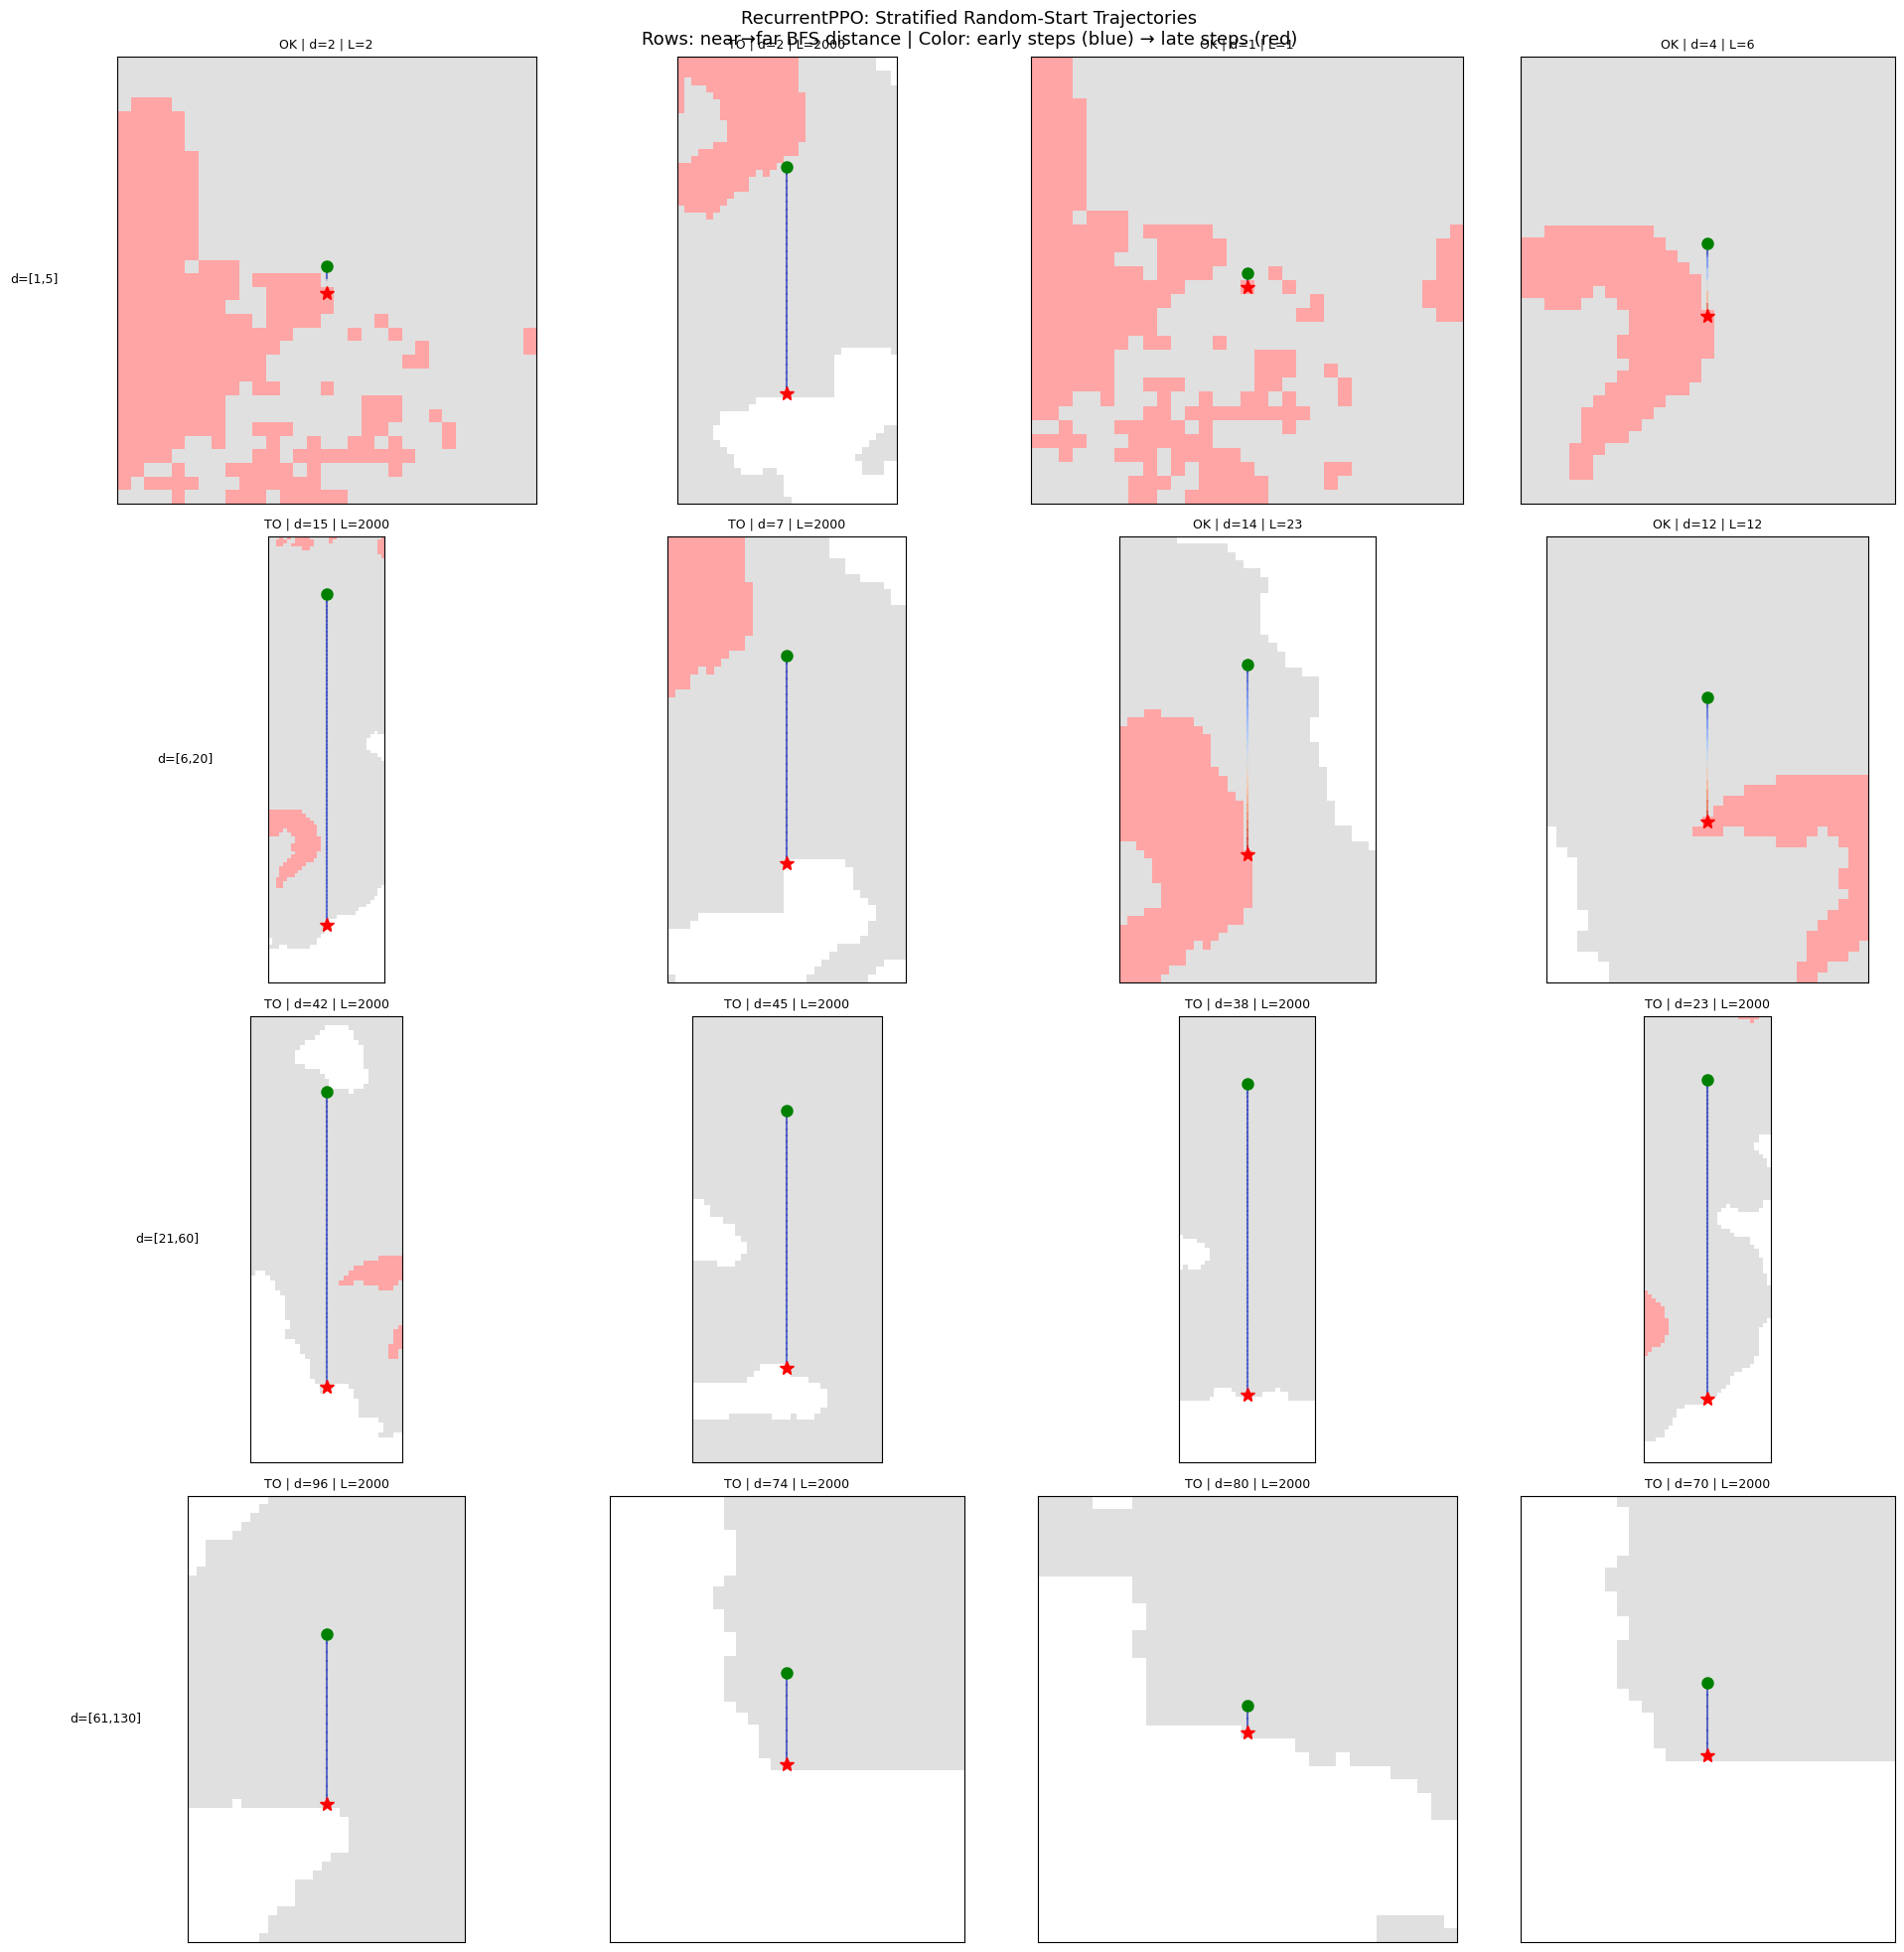


Distance range     SR       Avg length  
----------------------------------------
  [  1,  5]           75.0%       502.2
  [  6, 20]           50.0%      1008.8
  [ 21, 60]            0.0%      2000.0
  [ 61,130]            0.0%      2000.0


In [ ]:

# Sample trajectories across distance bands using a color gradient (blue=early, red=late)
# Start positions are stratified by BFS distance to get a spread of near/far cases

import matplotlib.cm as cm

rng_viz = np.random.RandomState(999)
N_VIZ = 16
COLS_VIZ = 4
ROWS_VIZ = N_VIZ // COLS_VIZ

vis_env2 = WSIEnv(H5_PATH, max_steps=MAX_STEPS, embedding_suffix=EMBEDDING_SUFFIX)
vis_env2._compute_distance_to_tumor()

# Sample 4 starts from each of 4 distance bands
dist_bins = [(1, 5), (6, 20), (21, 60), (61, 130)]
rand_starts = []
for d_lo, d_hi in dist_bins:
    pool_bin = vis_env2.get_start_pool(d_lo, d_hi)
    n_sample = min(4, len(pool_bin))
    idx_bin = rng_viz.choice(len(pool_bin), size=n_sample, replace=False)
    rand_starts += [(int(pool_bin[i][0]), int(pool_bin[i][1])) for i in idx_bin]
    if n_sample < 4:
        print(f"Distance [{d_lo},{d_hi}]: only {len(pool_bin)} tiles available")

N_VIZ = len(rand_starts)
ROWS_VIZ = N_VIZ // COLS_VIZ

# Run each episode with the RecurrentPPO model
rand_trajs = []
for start in rand_starts:
    vis_env2.fixed_starts = [start]
    vis_env2.start_mode = 'fixed'
    vis_env2._start_idx = 0

    obs, info = vis_env2.reset()
    traj = [(info['row'], info['col'])]
    total_r = 0.0
    done = False
    lstm_states = None
    ep_start = np.ones((1,), dtype=bool)

    while not done:
        action, lstm_states = model.predict(
            obs, state=lstm_states, episode_start=ep_start, deterministic=True
        )
        ep_start = np.zeros((1,), dtype=bool)
        obs, reward, terminated, truncated, info = vis_env2.step(action)
        traj.append((info['row'], info['col']))
        total_r += reward
        done = terminated or truncated

    bfs_d = int(vis_env2._dist_to_tumor[start[0], start[1]])
    rand_trajs.append({
        'start': start,
        'trajectory': traj,
        'reward': total_r,
        'length': len(traj) - 1,
        'success': info.get('success', False),
        'bfs_dist': bfs_d,
    })

vis_env2.close()

# Plot: color gradient along each trajectory; row label = distance band
bin_labels = [f"d=[{d_lo},{d_hi}]" for d_lo, d_hi in dist_bins]

fig, axes = plt.subplots(ROWS_VIZ, COLS_VIZ, figsize=(5 * COLS_VIZ, 5 * ROWS_VIZ))
fig.suptitle('RecurrentPPO: Stratified Random-Start Trajectories\n'
             'Rows: near→far BFS distance | Color: early steps (blue) → late steps (red)',
             fontsize=13)

for idx, ep in enumerate(rand_trajs):
    ax = axes[idx // COLS_VIZ, idx % COLS_VIZ]
    traj = ep['trajectory']
    tr = [t[0] for t in traj]
    tc = [t[1] for t in traj]

    margin = 15
    r0 = max(min(tr) - margin, 0);  r1 = min(max(tr) + margin + 1, vis_env2.n_rows)
    c0 = max(min(tc) - margin, 0);  c1 = min(max(tc) + margin + 1, vis_env2.n_cols)

    canvas = np.ones((r1 - r0, c1 - c0, 3))
    canvas[vis_env2.tissue_grid[r0:r1, c0:c1]] = [0.88, 0.88, 0.88]
    canvas[vis_env2.tumor_grid[r0:r1, c0:c1]] = [1.0, 0.65, 0.65]
    ax.imshow(canvas, origin='upper')

    sr = [r - r0 for r in tr]
    sc = [c - c0 for c in tc]
    n_seg = max(len(sr) - 1, 1)
    for j in range(n_seg):
        ax.plot(sc[j:j+2], sr[j:j+2], color=cm.coolwarm(j / n_seg), lw=1.5, alpha=0.8)

    ax.plot(sc[0], sr[0], 'go', ms=8, zorder=5)
    ax.plot(sc[-1], sr[-1], 'r*', ms=10, zorder=5)

    status = 'OK' if ep['success'] else 'TO'
    ax.set_title(f"{status} | d={ep['bfs_dist']} | L={ep['length']}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

    if idx % COLS_VIZ == 0:
        bin_i = idx // COLS_VIZ
        ax.set_ylabel(bin_labels[bin_i], fontsize=9, rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.show()

# Per-band success rate summary
print(f"\n{'Distance range':<18} {'SR':<8} {'Avg length':<12}")
print("-" * 40)
for b_i, (d_lo, d_hi) in enumerate(dist_bins):
    bin_eps = rand_trajs[b_i * 4: b_i * 4 + 4]
    sr_b = sum(e['success'] for e in bin_eps) / len(bin_eps) * 100
    al_b = np.mean([e['length'] for e in bin_eps])
    print(f"  [{d_lo:>3},{d_hi:>3}]          {sr_b:>5.1f}%  {al_b:>10.1f}")


## 10. Save Model

In [12]:
save_path = f"rppo_{RUN_TAG}"
model.save(save_path)
print(f"Saved: {save_path}.zip")

Saved: rppo_rppo_20260323_015450.zip


## 11. Summary

### Results

| Model | Architecture | Params | 2a (3-5) | 2b (10-20) | 2c (all tissue) | Train Time |
|-------|-------------|--------|----------|------------|-----------------|------------|
| MLP-PPO (NB6) | [256,256] MLP | ~1M | 48% | 20% | 6% | 17 min |
| RecurrentPPO | [256,256] + LSTM(256) | 4.2M | 54% | 28% | 20% | 144 min |

### Notes

RecurrentPPO beats MLP-PPO across all three distance bands — most notably on the hardest pool (2c: 20% vs 6%). That looks promising on paper, but the trajectory plots tell a different story.

Looking at the visualizations in cell 22, the successful episodes are almost universally a straight vertical line downward. The LSTM doesn't appear to be reading the observation sequence and inferring direction — it's just executing the same fixed-direction strategy as the MLP, only more consistently. The likely mechanism: the recurrent hidden state helps the agent commit to one direction without oscillating, which incidentally catches more tumors that happen to be directly below the start.

This rules out "MLP lacks temporal memory" as an explanation for the failure. Even with an LSTM that can remember its full observation history, the agent still degrades to a direction-agnostic walk. The problem isn't the policy architecture — it's that the observation sequence itself doesn't contain a recoverable directional gradient. On CAMELYON16, normal tissue embeddings don't vary systematically with spatial proximity to the tumor, so there's nothing for the LSTM to latch onto.

The conclusion from Notebook (6) stands: the bottleneck is the information content of the observation space, and no amount of architectural capacity fixes that.